# 1- Data Exploration

L'objectif de cette section est de charger le jeu de données PathMNIST et d'en comprendre la structure avant de construire le moindre modèle.

In [26]:
import medmnist
from medmnist import INFO, PathMNIST

In [27]:
# Récupération des données du dataset PathMNIST
data_flag = 'pathmnist'
info = INFO[data_flag]

print("--- STRUCTURE DU DATASET ---")
print(f"Tâche : {info['task']}")
print(f"Format des images : 28x28 avec {info['n_channels']} canaux (RGB)")
print(f"Classes disponibles : {info['label']}")

# Chargement des trois sous-ensembles du dataset
train_dataset = PathMNIST(split='train', download=True)
val_dataset = PathMNIST(split='val', download=True)
test_dataset = PathMNIST(split='test', download=True)

print(f"\nNombre d'images (Entraînement) : {len(train_dataset)}")
print(f"Nombre d'images (Validation) : {len(val_dataset)}")
print(f"Nombre d'images (Test) : {len(test_dataset)}")

# Calcul du total
total_images = len(train_dataset) + len(val_dataset) + len(test_dataset)
print(f"\nNombre total d'images à la base : {total_images}")

--- STRUCTURE DU DATASET ---
Tâche : multi-class
Format des images : 28x28 avec 3 canaux (RGB)
Classes disponibles : {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}

Nombre d'images (Entraînement) : 89996
Nombre d'images (Validation) : 10004
Nombre d'images (Test) : 7180

Nombre total d'images à la base : 107180


### **Analyse de la structure du Dataset**

D'après l'exploration initiale et les spécifications du projet, le dataset **PathMNIST** contient un total de **107 180 images** à la base. 

Ces images sont des patchs histologiques de cancer colorectal mesurant $28\times28$ pixels en couleurs (RGB). Elles sont réparties en 3 sous-ensembles :
- Un set d'**entraînement** (train) pour apprendre au modèle.
- Un set de **validation** (val) pour ajuster les paramètres pendant l'entraînement.
- Un set de **test** pour évaluer les performances finales.

Le dataset comprend 9 classes différentes, allant de "Background" (le fond) et "Debris" (les débris) à des tissus spécifiques comme "Tumor Epithelium".

### **Visualisation des données et Statistiques descriptives**

Avant de répondre aux questions spécifiques, nous explorons le jeu de données d'entraînement pour bien comprendre ce que nous allons manipuler. 

1. **Visualisation :** Nous allons afficher un exemple d'image pour chacune des 9 classes de tissus.  

2. **Descriptive Statistics :** Nous allons compter le nombre d'images par classe dans le set d'entraînement pour vérifier si le dataset est équilibré.

**1. Visualisation**

In [28]:
import matplotlib.pyplot as plt
import numpy as np

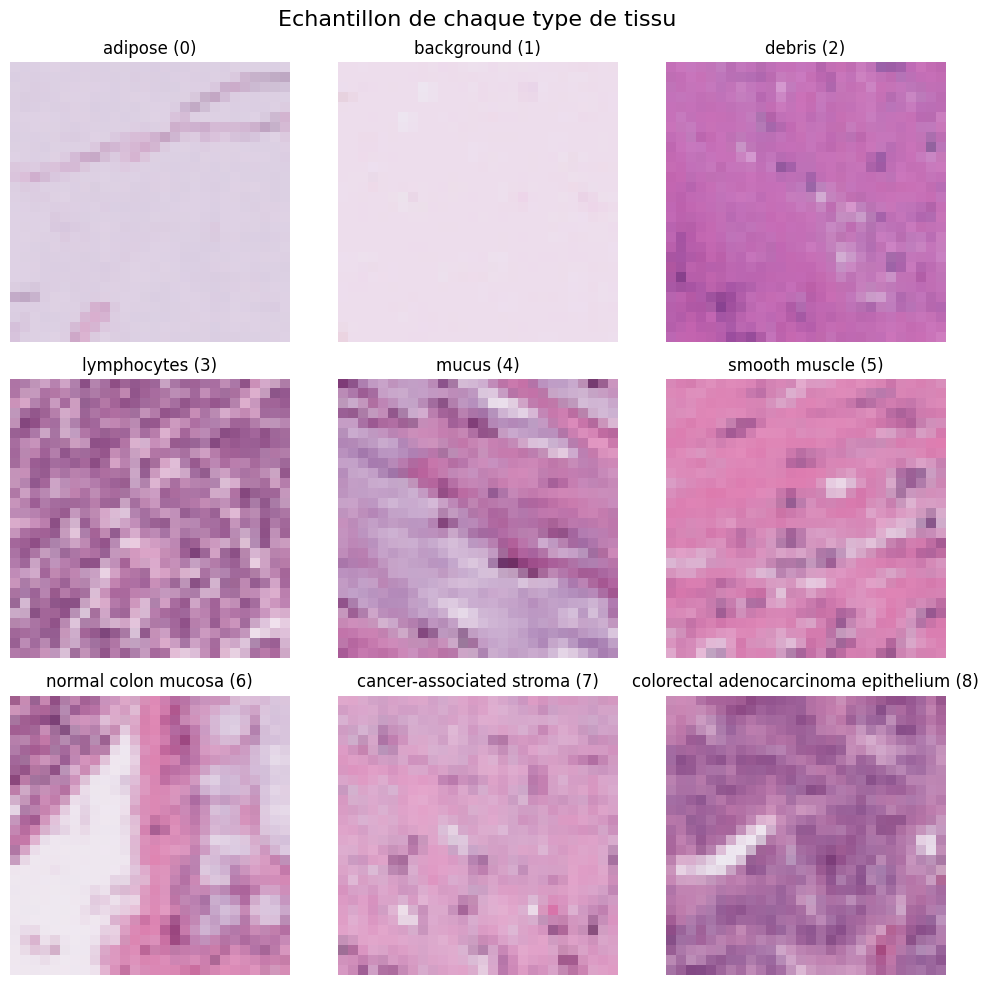

In [29]:
# Noms des classes selon les informations du dataset
class_dict = info['label']

# Afficher une image de chaque classe
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
axes = axes.flatten()

# On cherche une image pour chaque label (de 0 à 8)
for i in range(9):
    # Trouver le premier index correspondant à la classe 'i'
    idx = next(index for index, (_, label) in enumerate(train_dataset) if label[0] == i)
    img, label = train_dataset[idx]
    
    axes[i].imshow(img)
    axes[i].set_title(f"{class_dict[str(i)]} ({i})")
    axes[i].axis('off')

plt.suptitle("Echantillon de chaque type de tissu", fontsize=16)
plt.tight_layout()
plt.show()

**2. Descriptive Statistics** 

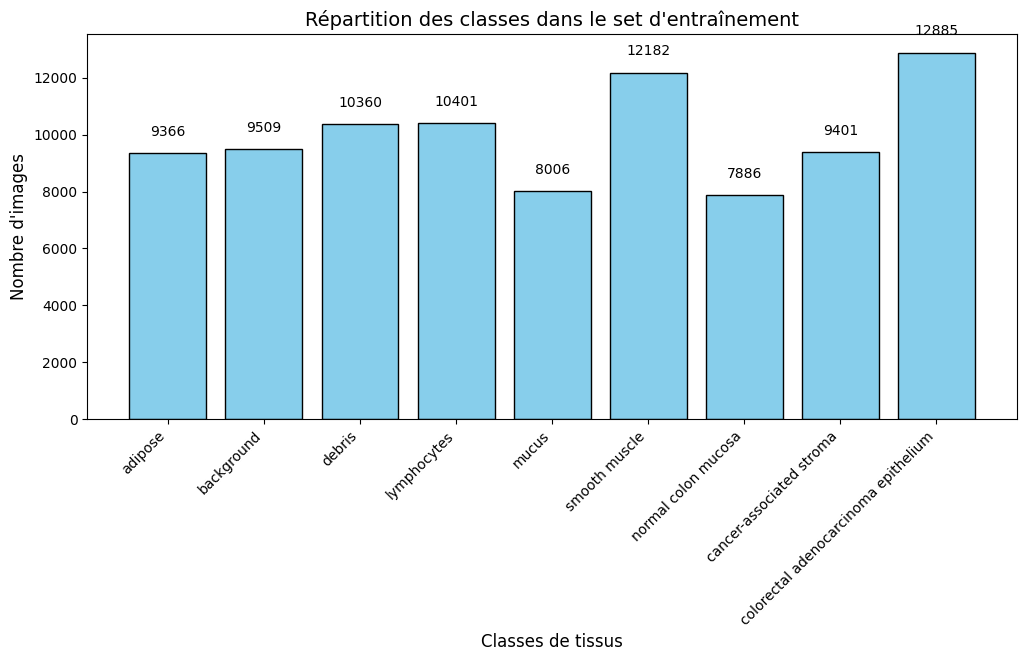

In [30]:
# On extrait tous les labels du set d'entraînement
all_labels = [label[0] for _, label in train_dataset]

# On compte les occurrences de chaque classe
classes, counts = np.unique(all_labels, return_counts=True)

# Affichage sous forme d'histogramme (Bar chart)
plt.figure(figsize=(12, 5))
bars = plt.bar(classes, counts, color='skyblue', edgecolor='black')

# Graphique
plt.title("Répartition des classes dans le set d'entraînement", fontsize=14)
plt.xlabel("Classes de tissus", fontsize=12)
plt.ylabel("Nombre d'images", fontsize=12)
plt.xticks(classes, [class_dict[str(c)] for c in classes], rotation=45, ha="right")

# Ajout des valeurs exactes au-dessus des barres
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 500, int(yval), ha='center', va='bottom', fontsize=10)

plt.show()

### **Q1.1 — Look at several images from the Debris class and several from Background. Describe in your own words what visual differences you observe between them. Include at least one specific observation about color or texture.**

On récupère respectivement 10 images des classes `Background` (Label 1) et `Debris` (Label 2) afin de comparer leur aspect visuel à partir de divers échantillons.

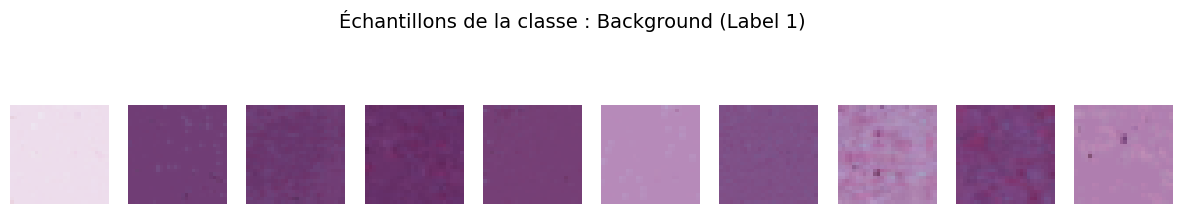

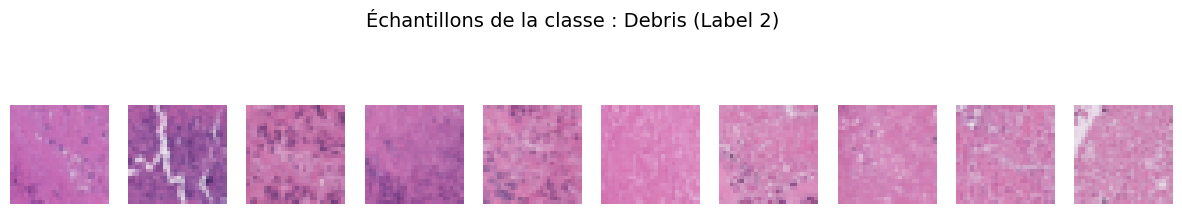

In [31]:
# Fonction pour récupérer et afficher 5 images d'une classe donnée
def plot_five_samples(dataset, label_idx, class_name):
    images = []
    # On parcourt le dataset jusqu'à trouver 5 images de la bonne classe
    for img, label in dataset:
        if label[0] == label_idx:
            images.append(img)
        if len(images) == 10:
            break
            
    # Création de la figure pour l'affichage
    fig, axes = plt.subplots(1, 10, figsize=(15, 3))
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')  # On masque les axes pour un rendu plus propre
        
    plt.suptitle(f"Échantillons de la classe : {class_name}", fontsize=14)
    plt.show()

# Affichage pour la classe Background (Label 1) et Debris (Label 2)
plot_five_samples(train_dataset, 1, "Background (Label 1)")
plot_five_samples(train_dataset, 2, "Debris (Label 2)")

Visuellement, on observe des différences très nettes entre les deux classes :  
  
**- `Background` :** L'image est vide de toute structure cellulaire et sa texture est lisse. Au niveau des couleurs, on observe soit un fond blanc très clair, soit une teinte violette complètement uniforme (probablement due au colorant sur la lame).  

**-`Debris` :** La texture est beaucoup plus granuleuse et irrégulière. L'image est remplie de petits fragments et de taches sans forme précise. L'ensemble de couleur est globalement un mélange de rose et de violet.

### **Q1.2— Pick any single image from the training set and report its pixel intensity statistics: mean and standard deviation per channel (R, G, B). Are these values close to ImageNet statistics ? Show the computation.**

In [32]:
import numpy as np

In [33]:
# On récupère une image au hasard du dataset d'entraînement (ici la 5645ème)
img, label = train_dataset[5645]

# On convertit l'image en tableau NumPy et on normalise les pixels entre 0 et 1 (division par 255)
img_array = np.array(img) / 255.0  

# Calcul de la moyenne et de l'écart-type par canal (R=0, G=1, B=2)
# axis=(0, 1) permet de moyenner sur la hauteur et la largeur de l'image (28x28)
means = img_array.mean(axis=(0, 1))
stds = img_array.std(axis=(0, 1))

print(f"--- Statistiques de l'image sélectionnée (Classe {label[0]}) ---")
print(f"Moyenne (R, G, B) : [{means[0]:.4f}, {means[1]:.4f}, {means[2]:.4f}]")
print(f"Écart-type (R, G, B) : [{stds[0]:.4f}, {stds[1]:.4f}, {stds[2]:.4f}]")

print("\n--- Statistiques standards de référence (ImageNet) ---")
print("Moyenne (R, G, B) : [0.485, 0.456, 0.406]")
print("Écart-type (R, G, B) : [0.229, 0.224, 0.225]")

--- Statistiques de l'image sélectionnée (Classe 7) ---
Moyenne (R, G, B) : [0.7797, 0.5061, 0.7052]
Écart-type (R, G, B) : [0.0514, 0.0916, 0.0608]

--- Statistiques standards de référence (ImageNet) ---
Moyenne (R, G, B) : [0.485, 0.456, 0.406]
Écart-type (R, G, B) : [0.229, 0.224, 0.225]


#### **Statistiques et comparaison ImageNet**

#### **Méthodologie**  

Pour obtenir ces statistiques, nous traitons l'image comme une matrice de pixels. Une image de 28x28 pixels en couleur contient $28 \times 28 = 784$ pixels par canal.
Chaque pixel a une valeur d'intensité comprise entre 0 et 255. Nous les normalisons d'abord entre 0 et 1 (en divisant par 255) pour pouvoir comparer avec les standards du domaine.

La **moyenne ($\mu$)** pour un canal (par exemple le Rouge) est calculée ainsi :
$$\mu = \frac{1}{784} \sum_{i=1}^{784} x_i$$

L'**écart-type ($\sigma$)**, qui mesure si les couleurs sont variées ou très proches, est calculé ainsi :
$$\sigma = \sqrt{\frac{1}{784} \sum_{i=1}^{784} (x_i - \mu)^2}$$

#### **Rapport des valeurs (Image n°5645)**  

- Moyenne (R, G, B) : [0.7797, 0.5061, 0.7052]  

- Écart-type (R, G, B) : [0.0514, 0.0916, 0.0608]

#### **Interprétation**  

Les valeurs sont **très éloignées**. Pour comprendre pourquoi, il faut savoir ce qu'est ImageNet.  
ImageNet est une base de données géante de plus de 14 millions de photos "naturelles" (des animaux, des objets, des paysages...). C'est la référence standard en IA pour calibrer les modèles.

Voici pourquoi nos statistiques sont différentes :

- Le contenu des images : ImageNet contient des photos de la vie réelle avec des couleurs équilibrées et variées. Nos images, elles, sont des échantillons médicaux colorés artificiellement en laboratoire. Le rose et le violet dominent, ce qui décale complètement les moyennes par rapport à une photo classique.  


- La luminosité : Les photos d'ImageNet ont beaucoup de contrastes et d'ombres. Nos images d'histologie ont souvent un fond très lumineux (microscope), ce qui explique pourquoi nos moyennes sont plus élevées.  


- L'échelle : ImageNet montre des objets entiers. Ici, on regarde un zoom minuscule de tissu. À cette échelle, les couleurs changent très peu d'un pixel à l'autre, ce qui donne un écart-type (une variété de couleurs) plus faible que sur des photos normales.